# Streaming Demo

This notebook shows the Assignment 2.2 package working on small data chunks.

In [1]:
import sys
from pathlib import Path

import numpy as np

sys.path.append(str(Path.cwd().parent if Path.cwd().name == 'demo' else Path.cwd()))

from numcompute_stream.ensemble import EnsembleClassifier
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.preprocessing import Imputer, StandardScaler
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.visualise import plot_metric_over_time

In [2]:
np.random.seed(4)
X = np.random.randn(80, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

X[5, 0] = np.nan
X[18, 1] = np.nan

chunks = []
chunk_size = 20
for start in range(0, len(X), chunk_size):
    end = start + chunk_size
    chunks.append((X[start:end], y[start:end]))

len(chunks)

4

In [3]:
pipe = Pipeline([
    ('imputer', Imputer()),
    ('scale', StandardScaler()),
    ('model', EnsembleClassifier(n_estimators=3, max_depth=3)),
])

trainer = StreamTrainer(pipe)

In [4]:
accuracies = []

for X_chunk, y_chunk in chunks:
    trainer.fit_chunk(X_chunk, y_chunk)
    row = trainer.score_chunk(X_chunk, y_chunk)
    accuracies.append(row['accuracy'])
    print('chunk', row['chunk'], 'accuracy', round(row['accuracy'], 3))

chunk 1 accuracy 0.9
chunk 2 accuracy 0.95
chunk 3 accuracy 0.95
chunk 4 accuracy 0.963


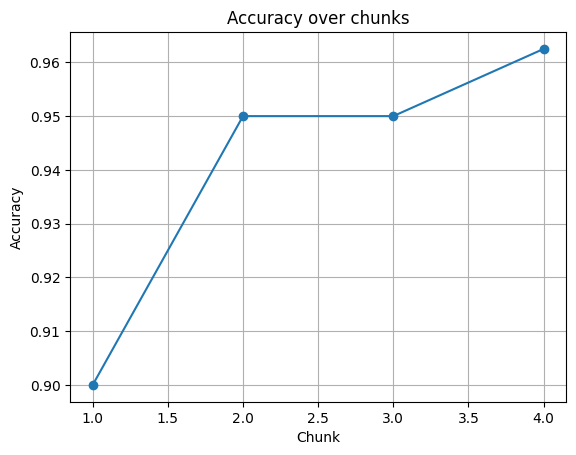

In [5]:
plot_metric_over_time(accuracies, title='Accuracy over chunks', ylabel='Accuracy')